#Mohammed Buhamad 
#2240005142
#7MA2

In [1]:
import os

IMAGES_DIR = os.path.join(os.getcwd(), "images")
os.makedirs(IMAGES_DIR, exist_ok=True)
print("Images folder:", IMAGES_DIR)


Images folder: c:\Users\xmoha\OneDrive\سطح المكتب\images


In [2]:
import urllib.request
import numpy as np
from PIL import Image

# Two independent mirrors per file, tried in order.
MIRRORS = {
    "lena_gray_256.tif": [
        "https://raw.githubusercontent.com/JuliaImages/TestImages.jl/gh-pages/images/lena_gray_256.tif",
        "http://www.eecs.northwestern.edu/~faisal/d20/lena.tif",
    ],
    "cameraman.tif": [
        "https://raw.githubusercontent.com/JuliaImages/TestImages.jl/gh-pages/images/cameraman.tif",
        "http://www.eecs.northwestern.edu/~faisal/d20/caman.tif",
    ],
}


def make_placeholder(path, label, size=256):
    """Last-resort synthetic stand-in so the rest of the lab can still run."""
    grad = np.tile(np.linspace(0, 255, size, dtype=np.uint8), (size, 1))
    yy, xx = np.mgrid[0:size, 0:size]
    mask = (xx - size / 2) ** 2 + (yy - size / 2) ** 2 < (size / 4) ** 2
    grad[mask] = 255 - grad[mask]
    img = Image.fromarray(grad, mode='L')
    img.save(path)
    print(f"  -> All mirrors failed for {label}. Wrote a PLACEHOLDER image to:\n     {path}")
    print(f"     (Steps will still run, but this is NOT the real {label}.)")


def fetch_and_validate(name, urls, dest_dir):
    dest = os.path.join(dest_dir, name)
    for url in urls:
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=20) as resp:
                data = resp.read()
            with open(dest, "wb") as f:
                f.write(data)
            # The critical step: confirm it's really a decodable image, not an
            # HTML error page or a broken/partial download.
            with Image.open(dest) as im:
                im.verify()
            print(f"{name}: downloaded and verified OK  <-  {url}")
            return
        except Exception as e:
            print(f"{name}: failed from {url}  ({e})")
    make_placeholder(dest, name)


for name, urls in MIRRORS.items():
    fetch_and_validate(name, urls, IMAGES_DIR)


lena_gray_256.tif: failed from https://raw.githubusercontent.com/JuliaImages/TestImages.jl/gh-pages/images/lena_gray_256.tif  (HTTP Error 404: Not Found)
lena_gray_256.tif: downloaded and verified OK  <-  http://www.eecs.northwestern.edu/~faisal/d20/lena.tif
cameraman.tif: failed from https://raw.githubusercontent.com/JuliaImages/TestImages.jl/gh-pages/images/cameraman.tif  (HTTP Error 404: Not Found)
cameraman.tif: downloaded and verified OK  <-  http://www.eecs.northwestern.edu/~faisal/d20/caman.tif


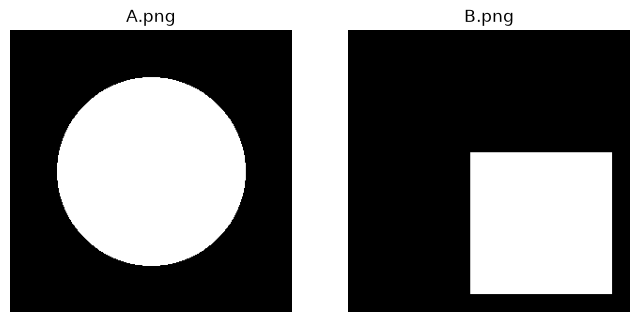

Saved A.png and B.png to c:\Users\xmoha\OneDrive\سطح المكتب\images


In [3]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

size = (300, 300)

# A.png: filled circle
imgA_gen = Image.new('L', size, 0)
ImageDraw.Draw(imgA_gen).ellipse([50, 50, 250, 250], fill=255)
imgA_gen.save(os.path.join(IMAGES_DIR, "A.png"))

# B.png: filled square, offset so it partially overlaps the circle
imgB_gen = Image.new('L', size, 0)
ImageDraw.Draw(imgB_gen).rectangle([130, 130, 280, 280], fill=255)
imgB_gen.save(os.path.join(IMAGES_DIR, "B.png"))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(imgA_gen, cmap='gray'); axes[0].set_title('A.png'); axes[0].axis('off')
axes[1].imshow(imgB_gen, cmap='gray'); axes[1].set_title('B.png'); axes[1].axis('off')
plt.show()

print("Saved A.png and B.png to", IMAGES_DIR)


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [5]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.

    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.

    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor),
                                interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.

    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.

    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.

    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()


In [6]:
image_path = os.path.join(IMAGES_DIR, 'lena_gray_256.tif')
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image at {image_path}")
else:
    # Sample and quantize
    sampled_image = sample_image(original_image, sampling_factor)
    quantized_image = quantize_image(original_image, quantization_levels)

    # Plot results
    plot_images(original_image, sampled_image, quantized_image)


Error: Unable to load image at c:\Users\xmoha\OneDrive\سطح المكتب\images\lena_gray_256.tif


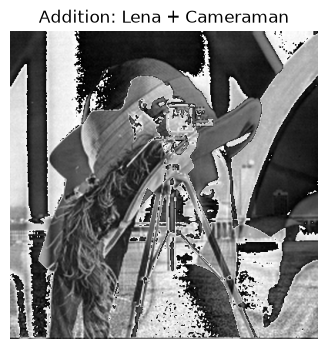

In [7]:
from PIL import Image

img1 = Image.open(os.path.join(IMAGES_DIR, 'lena_gray_256.tif'))
img2 = Image.open(os.path.join(IMAGES_DIR, 'cameraman.tif'))

resize = (400, 400)
img1 = img1.resize(resize, Image.Resampling.LANCZOS)
img2 = img2.resize(resize, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr        # matches the manual exactly (raw uint8 addition)
resultImage = Image.fromarray(addition)

plt.figure(figsize=(4, 4))
plt.imshow(resultImage, cmap='gray')
plt.title('Addition: Lena + Cameraman')
plt.axis('off')
plt.show()


---
# 3. Sets and Logical Operations


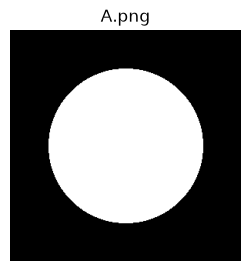

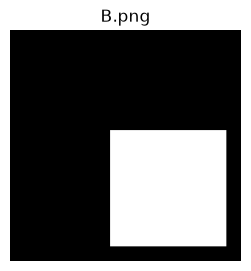

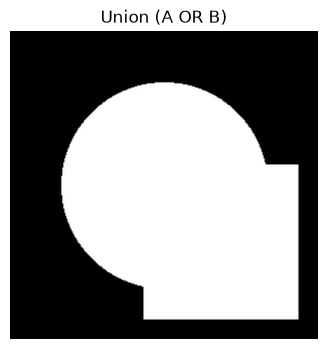

In [9]:
img3 = Image.open(os.path.join(IMAGES_DIR, 'A.png'))
plt.figure(figsize=(3, 3)); plt.imshow(img3, cmap='gray'); plt.title('A.png'); plt.axis('off'); plt.show()

img4 = Image.open(os.path.join(IMAGES_DIR, 'B.png'))
plt.figure(figsize=(3, 3)); plt.imshow(img4, cmap='gray'); plt.title('B.png'); plt.axis('off'); plt.show()

resize = (400, 400)
img3 = img3.resize(resize, Image.Resampling.LANCZOS)
img4 = img4.resize(resize, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union)

plt.figure(figsize=(4, 4))
plt.imshow(resultImage2, cmap='gray')
plt.title('Union (A OR B)')
plt.axis('off')
plt.show()


---
# 4. Practical Session Plan

## Task #1 — Change the sampling and quantization parameters and observe the effects

Below, `lena_gray_256.tif` is sampled at several factors (quantization fixed at 9 levels) and quantized at several levels (sampling fixed at factor 1, i.e. no downsampling), so each parameter's effect is isolated.


TypeError: Image data of dtype object cannot be converted to float

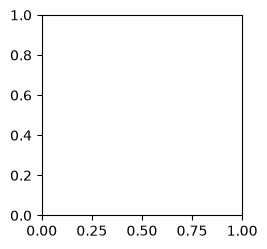

In [8]:
base_image = cv2.imread(os.path.join(IMAGES_DIR, 'lena_gray_256.tif'), cv2.IMREAD_GRAYSCALE)

# --- Effect of the SAMPLING factor (quantization levels held constant at 9) ---
sampling_factors_to_try = [1, 2, 4, 8, 16]

plt.figure(figsize=(15, 3))
for i, factor in enumerate(sampling_factors_to_try):
    sampled = sample_image(base_image, factor) if factor > 1 else base_image
    plt.subplot(1, len(sampling_factors_to_try), i + 1)
    plt.imshow(sampled, cmap='gray')
    plt.title(f'factor={factor}\n{sampled.shape[1]}x{sampled.shape[0]}')
    plt.axis('off')
plt.suptitle('Effect of the sampling factor (quantization = 9 levels)')
plt.show()


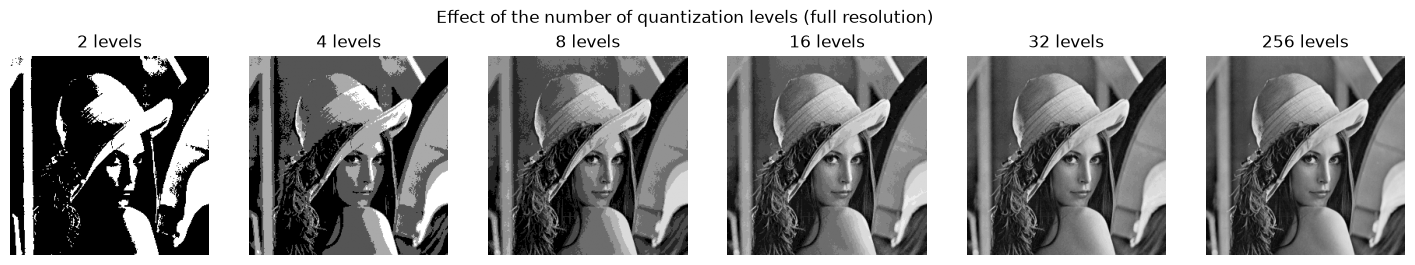

In [ ]:
# --- Effect of QUANTIZATION levels (sampling factor held at 1, i.e. full resolution) ---
levels_to_try = [2, 4, 8, 16, 32, 256]

plt.figure(figsize=(18, 3))
for i, levels in enumerate(levels_to_try):
    quantized = quantize_image(base_image, levels)
    plt.subplot(1, len(levels_to_try), i + 1)
    plt.imshow(quantized, cmap='gray')
    plt.title(f'{levels} levels')
    plt.axis('off')
plt.suptitle('Effect of the number of quantization levels (full resolution)')
plt.show()


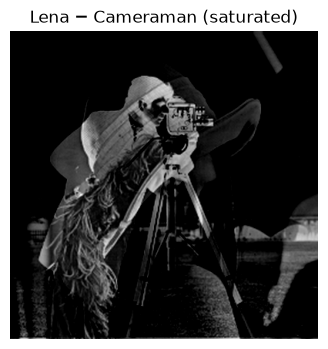

In [ ]:
# cv2.subtract saturates at 0 instead of wrapping around like plain NumPy subtraction would
subtracted = cv2.subtract(im1arr, im2arr)

plt.figure(figsize=(4, 4))
plt.imshow(subtracted, cmap='gray')
plt.title('Lena − Cameraman (saturated)')
plt.axis('off')
plt.show()


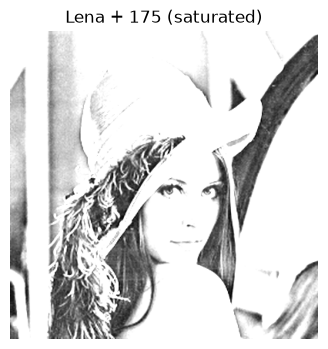

In [ ]:
# cv2.add saturates at 255 instead of wrapping around like plain NumPy addition would
added_constant = cv2.add(im1arr, 175)

plt.figure(figsize=(4, 4))
plt.imshow(added_constant, cmap='gray')
plt.title('Lena + 175 (saturated)')
plt.axis('off')
plt.show()


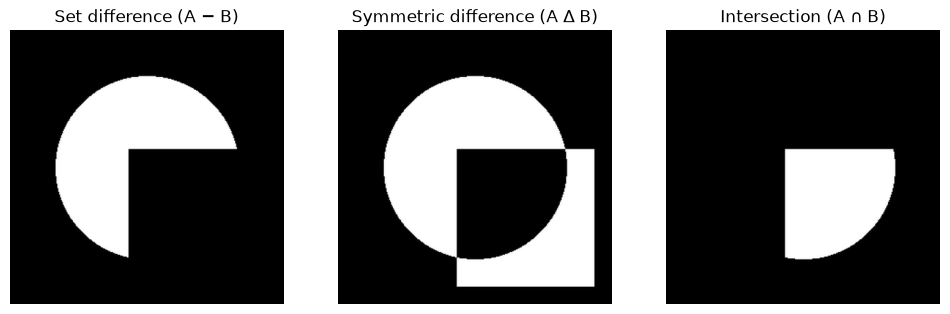

In [ ]:
set_difference = cv2.bitwise_and(im3arr, cv2.bitwise_not(im4arr))     # A - B  (A AND NOT B)
symmetric_difference = cv2.bitwise_xor(im3arr, im4arr)                # A XOR B
intersection = cv2.bitwise_and(im3arr, im4arr)                        # A AND B

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(set_difference, cmap='gray'); axes[0].set_title('Set difference (A − B)'); axes[0].axis('off')
axes[1].imshow(symmetric_difference, cmap='gray'); axes[1].set_title('Symmetric difference (A ∆ B)'); axes[1].axis('off')
axes[2].imshow(intersection, cmap='gray'); axes[2].set_title('Intersection (A ∩ B)'); axes[2].axis('off')
plt.show()
